# Partikelfysik

Som nævnt, er du blevet udnævnt personligt til at klassificere elektroner på CERN. Men før vi går i gang, skal vi have hentet nogle "pakker". Tænk på det som nogen der har skrevet noget kode vi kan importere, så vi ikke skal gøre alting fra bunden. Når du kører cellen herunder, importerer og installerer den automatisk det vi skal bruge.

In [ ]:
# Importer pakker der skal bruges
%pip install -q numpy matplotlib scikit-learn lightgbm graphviz ipython scipy 

# Data
import numpy as np
import scipy as scipy

# Plotting
import matplotlib.pyplot as plt

# Sklearn: et librabry med en masse funtioner vi bruger i Machine Learning
import sklearn

# Graphviz - Pakke der kan visualisere decision trees
from IPython.display import SVG, display
from graphviz import Source

# LightGBM - pakke til at køre decision tree
import lightgbm as lgb
from lightgbm import early_stopping

## Inspicer dataen

Først vil vi gerne undersøge hvilken data vi har med at gøre.

In [ ]:
data = np.genfromtxt('partikel_data.csv', delimiter=',', names=True, dtype=None, encoding=None)

variable = data.dtype.names
input_variable = [v for v in variable if v != 'p_Truth_isElectron']
input_data = np.column_stack([data[v] for v in input_variable])
truth_data = data['p_Truth_isElectron']

# Print first 5 rows with names
print(" | ".join(variable))
for row in data[:5]:
    print(" | ".join(str(row[v]) for v in variable))

# Decision Tree

Et decision tree er bygget op af lag og grene. Ved hver gren stiller den et spørgsmål, og bevæger sig ned i det næste lag baseret på om spørgsmålet er sandt eller falsk. Og ved at lære af en masse data, kan den finde ud af hvilke spørgsmål der er bedst at stille.

### Parameter
For et decision tree kan vi justere på hvor mange lag der skal være i vores træ, altså hvor mange lag af spørgsmål der må stilles. Vi kan justere på den parameter herunder.

In [3]:
DT_N_lag = 2                # Hvor mange lag der er i træet

Her bygger og træner vi modellen og bruger Graphviz til at visualisere det.

Max dybde af træet: 2


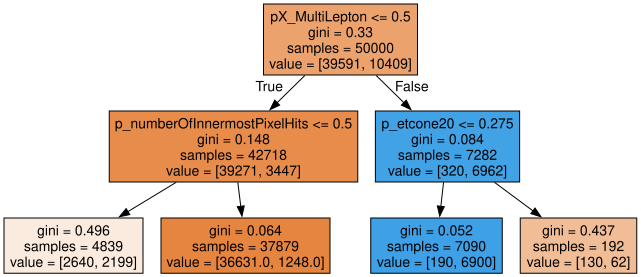

In [4]:
# Her bliver modellen trænet på data
estimator = sklearn.tree.DecisionTreeClassifier(max_depth=DT_N_lag, min_samples_leaf = 20,random_state=42)

estimator.fit(input_data, truth_data)   # Dette er den "magiske" linje - her optimerer Machine Learning algoritmen sine interne vægte til at give bedste svar

# laver visuel graf af træet
dot = sklearn.tree.export_graphviz(estimator, out_file=None, feature_names=input_variable, filled=True, max_depth=50)         
dot = dot.replace("squared_error", "error").replace("mse", "error")
graph = Source(dot)
print("Max dybde af træet:", estimator.get_depth())
display(SVG(graph.pipe(format='svg')))


### Spørgsmål:

- Inspicer træet. Forstår du/I, hvad de forskellige tal betyder?
  Hvad sker der fra lag til lag og hvor mange samples er der i hver kasse?
- Prøv at ændre på hvor mange lag der er i træet fra 2 til 3.
  Hvilke parametre bruges til at opdele data? 
- Hvordan ændres værdien af gini ift. om der kun er elektroner/ikke-elektroner eller begge typer?

## Boosted Decision Tree

Nu hvor vi har set hvordan træet virker, vil vi gerne prøve at forudsige typen af partikler som vi ikke kender typen af på forhånd.
Som vi har set, kan det være svært at minimere vores 'loss function'. En måde at forbedre på er ved at køre boosted decision trees, hvilket vil sige at vi kører flere træer, hvor den hver gang lærer af fejlene fra det forrige træ, og på den måde bliver "boostet" for hvert træ den laver. Herunder kan vi ændre hvor mange gange den må "booste", altså hvor mange træer den må lave og lære af.

In [5]:
boosting_rounds = 100      # Hvor mange runder af træer den må lave og lære af

Vi kan også vælge hvor stor en andel af data vi vil bruge. 

In [6]:
andel_af_data = 1.0  #Vælg hvor stor andel. Tallet skal være mellem 0 og 1.0.

#Vi omdefinerer vores input og truth data til kun at indeholde en del af dataene.
input_data_justeret, truth_data_justeret = sklearn.utils.resample(
    input_data, truth_data, 
    n_samples=int(andel_af_data * len(input_data)), 
    random_state=42, 
    replace=False
    )

Vi splitter data i et træningssæt og et testsæt.
Træningssættet bruges til at træne modellen, hvor modellen får at vide om data er en elektron eller ej.
Testsættet bruges til at give den trænede model ny data (som den ikke kender svaret til), som den så skal forudsige, men hvor vi stadig kender svaret.

In [7]:
data_train, data_test, label_train, label_test = \
    sklearn.model_selection.train_test_split(input_data_justeret, truth_data_justeret, test_size=0.25, random_state=42)

In [ ]:
# Her bygger vi modellen op med flere træer, træner på data og forudsiger priser

gbm_test = lgb.LGBMClassifier(n_estimators=boosting_rounds,# num_leaves=6,
                              boosting_type='gbdt', objective='binary', 
                              random_state=42)

gbm_test.fit(data_train, label_train, eval_set=[(data_test, label_test)], 
            callbacks=[early_stopping(15)])

Forudsigelse = gbm_test.predict_proba(data_test, num_iteration=gbm_test.best_iteration_)[:,1]

In [9]:
#Funktion der visualiserer resultaterne
def Plotting(label_test, Forudsigelse):

    #ROC
    #Udregn raten af sande/falske fordusigelser
    fpr, tpr, _ = sklearn.metrics.roc_curve(label_test, Forudsigelse)    
    #AUC score
    auc_score = sklearn.metrics.auc(fpr,tpr)  

    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(10, 6))

    #Plotting
    axs[0].set_title('ROC-curve', size = 10)
    axs[0].plot(fpr, tpr, label=f'(AUC = {auc_score:5.3f})')
    axs[0].legend(fontsize=10, loc ='lower right')
    axs[0].set_xlabel('False Positive Rate', size=10)
    axs[0].set_ylabel('True Positive Rate', size=10)
    axs[0].grid(True, alpha=0.3)

    #Histogram
    sandsynlighed_falsk = Forudsigelse[label_test == 0]
    sandsynlighed_korrekt = Forudsigelse[label_test == 1]

    #Plotting
    axs[1].hist(sandsynlighed_falsk, bins=30, alpha=0.6, color='lightblue', 
                   label=f'Ikke elektron (n={len(sandsynlighed_falsk)})', edgecolor='black')
    axs[1].hist(sandsynlighed_korrekt, bins=30, alpha=0.6, color='lightcoral', 
    label=f'Elektron (n={len(sandsynlighed_korrekt)})', edgecolor='black')
    axs[1].set_xlabel('Forudsagt sandsynlighed for at det er en elektron')
    axs[1].set_ylabel('Antal')
    axs[1].set_title('Fordeling af forudsagte sandsynligheder farvekodet efter sande værdier',size=10)
    axs[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Beslutningsgrænse (0.5)')
    axs[1].legend(loc='upper center')
    axs[1].yaxis.tick_right()
    axs[1].yaxis.set_label_position("right")
    axs[1].grid(True, alpha=0.3)


    plt.tight_layout()  
    plt.show()

In [ ]:
Plotting(label_test, Forudsigelse)

### Evaluer resultat med AUC og histogram
Nu vil vi gerne inspicere hvor god vores model er til at forusige på data hvor den ikke ved om data tilsvarer en elektron eller ej. Det venstre plot viser en ROC-kurve dvs. hvor stor en andel af sande gæt har vi per andel af forkerte gæt. Jo tættere denne er på venstre øverste hjørne jo bedre. Dvs. når raten af forkerte gæt er 0.1 er raten af korrekte gæt allrede omkring 0.9.

Selve scoren Area Under Curve (AUC) angiver bare hvor tæt på hjørnet grafen er. En score på 1 angiver en perfekt score.

Det højre plot viser fordelingen af korrekte og forkerte gæt farvekodet efter hvad data rent faktisk svarede til. Dvs vi kigger på hvad modellen har gættet på ud fra hvad vores data rent faktisk svarede til. 
Den røde linjer svarer til den grænse modellen bruger til at afgøre hvad den skal gætte på alt efter hvilken sandsynlighed den forudsiger.



### Spørgsmål:
- Ændr på antallet af boosting_rounds og se hvad der sker med modellene og resultatet. Kan du se forskel i performance for f.eks. 1, 10, 100, 1000 boosting_rounds?
- Hvad sker der med fordelingen af data i højre plot når du ændrer på boosting_rounds? Kan du stadig godt klassificere elektroner ved boosting_rounds=1 eller boosting_rounds=10? (Bemærk den stiplede linje er defineret ved 0.5 og modellen har ikke indflydelse på den.)
- Leg rundt med andelen af data du bruger. Hvordan ændres resultatet alt efter hvor meget data den har. Hvor meget data skal du bruge for at have en rimelig model og forudsigelse?

### Hvilke variable er vigtigst?
Vi kan tjekke om vores hvilke variabler der er vigtigst for modellen til at lave en forudsigelse med "permutation importance". Det er et mål for hvis værdierne i en kolonne bliver byttet rundt randomly, hvor meget påvirker det så resultatet. Hvis det er en vigtig variabel, vil det påvirke resultatet meget. Her bliver det mål på hvor meget større mean squared error bliver, når den variabel bliver "scramblet".

In [11]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names, but .* was fitted with feature names")

# Calculate permutation importance
perm_importance = sklearn.inspection.permutation_importance(gbm_test, data_test, label_test,scoring='neg_log_loss', random_state=42)
order = perm_importance.importances_mean.argsort()[::1]
labels = np.asarray(variable[:-1])[order]
vals = perm_importance.importances_mean[order]

In [ ]:
#Plot Resultat af Permutation Importance
plt.figure(figsize=(8, 6))
y = np.arange(len(vals))
plt.barh(y, vals)
plt.yticks(y, labels)
plt.xlabel("Increase in log_loss (permutation)")
plt.ylabel("Feature")
plt.title("Permutation Importance")
plt.tight_layout()
plt.show()

# Neurale Netværk

Neurale Netværk (NN) kommer fra at opbygningen af det, minder om den måde vores neuroner i hjernen snakker sammen på. På samme måde som et decision tree er der forskellige lag og vi kan styre hvor mange lag der er, men nu er det ikke kun sandt eller falsk, i stedet fungerer noderne som knapper der kan fintunes. 

Neurale netværk er mere følsomme overfor det data vi giver dem. Den fungerer bedst hvis data er værdier mellem 0 og 1. Derfor bruger vi en funktion til at skalere vores data, kaldet StandardScaler.

In [13]:
scaler = sklearn.preprocessing.StandardScaler()

data_train_transformed = scaler.fit_transform(data_train)
data_test_transformed = scaler.transform(data_test)

In [14]:
layer_one   = 32            # Her definerer vi hvor mange lag der skal være, og hvor mange 'neuroner' eller noder 
layer_two   = 16            # hvert lag skal have. Prøv at ændre på antal noder 
layer_three = 8             # for at forbedre din model
layer_four  = 4
layer_five  = 2
layer_six   = 2

Nedenfor træner vi modellen. Vi kan også regne ud hvor mange parametre modellen bruger.
Herefter plotter vi for at se hvor godt modellen klarer sig.

In [ ]:
# Her definerer og træner vi modellen
mlp = sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(layer_one, layer_two, layer_three, layer_four, layer_five, layer_six), 
max_iter=2000, early_stopping=True, random_state=42)
mlp.fit(data_train_transformed, label_train) 

# Her giver vi den trænede model test data som den ikke har set før, og beder om at forudsige prisen
Forudsigelse = mlp.predict_proba(data_test_transformed)[:,1]  

# Beregn antal parametre i modellen
# Coef er vægtene er intercept er bias. Den henter antallet directe fra modellen.
n_params = sum(coef.size + intercept.size for coef, intercept in zip(mlp.coefs_, mlp.intercepts_))
print(f"Antal parametre i NN: {n_params}")

In [ ]:
Plotting(label_test, Forudsigelse)


### Spørsgmål:
- Sammenlign modellen med boosted decision tree ovenover. Hvilken algoritme klarer sig bedst?
- Ændr antallet af neuroner per lag/antallet af lag og se hvordan performance ændrer sig.
- Får du det samme antal parametre når du regner efter?
- Leg rundt med andelen af data du bruger. Hvordan ændres resultatet alt efter hvor meget data den har. Hvor meget data skal du bruge for at have en rimelig model og forudsigelse?


### Avancerede spørgsmål:

Til hvis du vil bruge mere tid og finder ovenstående opgaver overskuelige.

- Leg rundt med hyperparametre (HP) i begge modeller (BDT og NN). Tilføj og fjern, ændr deres værdier, kør modellen og se hvordan den performer.  

    For BDT er nogen af dem:
    - num_leaves = integer (default = 31)    (hvor mange kasser seperate kasser må modellen maksimalt lave. )
    - boosting_type = 'gbdt', 'dart', 'rf' (default = 'gbdt') (Hvilken algoritme bruger vi til at booste)
    - max_depth = integer (default = -1 (negativt betyder ingen limit)) (hvor mange lag må der maksimalt være i vores træ)
    - learning_rate = integer (default = 0.1) (hvor store skridt modellen tager når den vil optimere loss function. Store skridt medfører den kan udforske mere, små skridt medfører den kan lave finere justeringer)
    - min_child_samples = integer (default = 20) (hvor mange samples skal der minimum være i en kasse)  
    Find hele listen af disse på: https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html  
    
    For NN er nogen af dem:
    - activation = 'logistic', 'tanh', 'relu' (default = 'relu') (Hvilken activation function vil vi bruge for hvert lag)
    - learning_rate = 'constant', 'invscaling', 'adaptive' (default = 'constant') (hvordan opfører learning rate sig under træningens forløb, se forklaring ovenfor under BDT)
    - max_iter = integer (default = 200) (hvor mange iterationer af modellen skal vi køre for at optimere (kan sammenlignes med boosting_rounds for BDT))
    - alpha = decimal (default = 0.0001) (intern parameter i loss function som skal forhindre at modellen overfitter, dvs lærer træningsdata alt for godt at kende så man ikke længere kan anvende den på ny data)  
    Find hele listen af disse på: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html  



- Prøv at optimere modellen så du får den bedste performace (AUC) ved at prøve forskellige kombinationer af HP af. Kan du komme i tanke op måder man ville kunne optimere/strukturere denne process på?  
- Slå sklearn's GridSearchCV og RandomizedSearchCV op og find ud af hvad de gør. Hvad er fordele/ulemper ved begge?
- Fjern early_stopping. Hvad gør det. Er det en fordel? Kan du risikere at overtræne hvis du ikke gør?
- Kør modellen på det store fulde datasæt. Hvilke parametre er der? Hvilke parametre er vigtige? Hvor meget data er der? Tager det længere tid? Husk at sørge for at den rigtige variabel er valgt til at lave regression/klassifikation efter, de kan hedde noget andet i de store filer.

- Er alle kolonner lige vigtige? Kør modellerne med kun de 5 bedste/værste variable og se deres performance. Nedenstående kode gør dette. 
Sæt denne ind lige efter cellen der "Inspicerer Data" og kør så hele filen igen.

In [ ]:
#På linjen under kan du vælge hvilke variable skal være med. Efterlad kun dem du vil bruge.
input_variabler = ['haeldning_300m', 'elevation', 'mass_balance', 'haeldning_adaptiv', 'hastighed_x', 'retning', 'hastighed_y', 'afstand_til_kant_km', 'areal']
variabler =  input_variabler + ['gletsjer_dybde']
selected_indices = [input_variabler.index(col) for col in input_variabler]
input_data = input_data[:, selected_indices]